# Análisis Exploratorio Unificado — Maestro de Materiales M402
## Todos los Tipos · Corporación Multi Inversiones · Junio 2026
---
**Proyecto:** GAMMA — Gobierno Automatizado del Maestro de Materiales  
**Equipo:** Alejandra Alvarado · Rudy Osorio · Erick Marroquin  
**Programa:** MBIA · Universidad del Valle de Guatemala  
**Fecha corte datos:** 29 de mayo 2026

### Objetivo del EDA Unificado
Consolidar el análisis exploratorio de los 11 tipos de material del Mandante 402 para:
1. Cuantificar el problema de duplicidad real a nivel de catálogo completo
2. Comparar la calidad de datos entre tipos de material
3. Identificar los tipos con mayor riesgo y prioridad de intervención
4. Fundamentar con datos reales el impacto de GAMMA en el catálogo del M402


In [1]:
# ── Resolucion de rutas (agregado al importar al repositorio GAMMA) ──────
# Localiza data/xlsx tanto dentro del contenedor Jupyter como en ejecucion local,
# sin importar la profundidad del notebook respecto de lab/.
import os

def _find_data_dir():
    if os.path.isdir('/home/jovyan/work/data/xlsx'):
        return '/home/jovyan/work/data/xlsx'
    d = os.path.abspath('.')
    for _ in range(6):
        cand = os.path.join(d, 'data', 'xlsx')
        if os.path.isdir(cand):
            return cand
        d = os.path.dirname(d)
    raise FileNotFoundError('No se encontro el directorio data/xlsx')

DATA_DIR = _find_data_dir()
FIG_DIR  = os.path.join(os.path.abspath('.'), 'figuras')
os.makedirs(FIG_DIR, exist_ok=True)
print('DATA_DIR:', DATA_DIR)
print('FIG_DIR :', FIG_DIR)


DATA_DIR: /Users/menene/code/www/mbia_gamma/lab/data/xlsx
FIG_DIR : /Users/menene/code/www/mbia_gamma/lab/notebooks/eda/figuras


## 0. Configuración y Carga de Todos los Tipos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ── Paleta corporativa CMI ───────────────────────────────────────────────
CMI_VERDE  = '#1A6635'
CMI_CLARO  = '#D6EFE0'
CMI_ORO    = '#C9A84C'
CMI_GRIS   = '#4A4A4A'
CMI_ROJO   = '#C0392B'
BLANCO     = '#FFFFFF'

# ── Archivos por tipo ─────────────────────────────────────────────────────
ARCHIVOS = {
    'ZRPA':                  'ZRPA_29MAY26.xlsx',
    'ZQUI':                  'ZQUI_29MAY26.xlsx',
    'ZMER/MOB/OFI/VEH/TUB':  'ZMER MOB OFI VEH TUB_29MAY26.xlsx',
    'ZMAQ':                  'ZMAQ_29MAY26.xlsx',
    'ZMAF':                  'ZMAF_29MAY26.xlsx',
    'ZHER':                  'ZHER_29MAY26.xlsx',
    'ZHAR':                  'ZHAR_29MAY26.xlsx',
    'ZEQU':                  'ZEQU_29MAY26.xlsx',
    'ZSUM':                  'ZSUM_29MAY26.xlsx',
    'ZSEG':                  'ZSEG_29MAY26.xlsx',
    'ZRPI':                  'ZRPI_29MAY26.xlsx',
}
CATALOGO = 'Clases de material DEN.xlsx'

# ── Carga unificada ──────────────────────────────────────────────────────
dfs = {}
errores = []

for tipo, archivo in ARCHIVOS.items():
    try:
        df = pd.read_excel(os.path.join(DATA_DIR, archivo))
        if 'Texto breve de material.1' in df.columns:
            df = df.rename(columns={'Texto breve de material.1': 'Texto_breve_2'})
        dfs[tipo] = df
        print(f'  ✓  {tipo:<25} {len(df):>7,} registros')
    except Exception as e:
        errores.append(tipo)
        print(f'  ✗  {tipo:<25} ERROR: {e}')

df_cls = pd.read_excel(os.path.join(DATA_DIR, CATALOGO))
print(f'\nTotal tipos cargados: {len(dfs)}')
print(f'Clases en catálogo:   {len(df_cls):,}')
if errores:
    print(f'Errores al cargar:    {errores}')


  ✓  ZRPA                          337 registros
  ✓  ZQUI                        5,667 registros


  ✓  ZMER/MOB/OFI/VEH/TUB        2,552 registros
  ✓  ZMAQ                           93 registros
  ✓  ZMAF                           80 registros
  ✓  ZHER                        2,033 registros
  ✓  ZHAR                          384 registros
  ✓  ZEQU                          145 registros


  ✓  ZSUM                       13,399 registros
  ✓  ZSEG                        2,626 registros


  ✓  ZRPI                       15,861 registros

Total tipos cargados: 11
Clases en catálogo:   1,539


## 1. Resumen Global del Catálogo M402
> Vista consolidada de todos los tipos de material. Base del análisis para GAMMA.


In [3]:
# ── Función helper para detectar columnas clave ──────────────────────────
def get_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# ── Resumen consolidado ──────────────────────────────────────────────────
resumen = []
for tipo, df in dfs.items():
    col_txt = get_col(df, ['Texto breve de material', 'Texto_breve_2'])
    col_pb  = get_col(df, [c for c in df.columns if 'PB' in c or 'nivel' in c.lower()])
    
    n_total = len(df)
    n_dup   = df.duplicated(subset=[col_txt], keep=False).sum() if col_txt else 0
    n_bloq  = (df[col_pb] == 'X').sum() if col_pb else 0
    
    tiene_sep = df[col_txt].astype(str).str.contains(r'[:/;]', regex=True) if col_txt else pd.Series([True]*n_total)
    n_sin_sep = (~tiene_sep).sum()
    
    col_unspsc = get_col(df, ['Info fabr./insp.', 'Info fabr/insp.'])
    n_sin_uns  = df[col_unspsc].isna().sum() if col_unspsc else 0
    
    col_clase = get_col(df, ['Denom.estándar', 'Denom. estándar', 'Denominación estándar'])
    n_sin_cls = df[col_clase].isna().sum() if col_clase else 0
    
    resumen.append({
        'Tipo': tipo,
        'Total': n_total,
        'Duplicados exactos': n_dup,
        '% Duplicados': round(n_dup/n_total*100, 1) if n_total > 0 else 0,
        'Bloqueados': n_bloq,
        '% Bloqueados': round(n_bloq/n_total*100, 1) if n_total > 0 else 0,
        'Sin separador': n_sin_sep,
        '% Sin sep.': round(n_sin_sep/n_total*100, 1) if n_total > 0 else 0,
        'Sin clase': n_sin_cls,
        '% Sin clase': round(n_sin_cls/n_total*100, 1) if n_total > 0 else 0,
    })

df_res = pd.DataFrame(resumen).set_index('Tipo')
total_row = pd.DataFrame([{
    'Total': df_res['Total'].sum(),
    'Duplicados exactos': df_res['Duplicados exactos'].sum(),
    '% Duplicados': round(df_res['Duplicados exactos'].sum()/df_res['Total'].sum()*100, 1),
    'Bloqueados': df_res['Bloqueados'].sum(),
    '% Bloqueados': round(df_res['Bloqueados'].sum()/df_res['Total'].sum()*100, 1),
    'Sin separador': df_res['Sin separador'].sum(),
    '% Sin sep.': round(df_res['Sin separador'].sum()/df_res['Total'].sum()*100, 1),
    'Sin clase': df_res['Sin clase'].sum(),
    '% Sin clase': round(df_res['Sin clase'].sum()/df_res['Total'].sum()*100, 1),
}], index=['TOTAL M402'])

df_final = pd.concat([df_res, total_row])
print('RESUMEN CONSOLIDADO — MAESTRO DE MATERIALES M402')
print('=' * 90)
print(df_final[['Total','Duplicados exactos','% Duplicados','Bloqueados','% Bloqueados','Sin separador','% Sin sep.']].to_string())
print('=' * 90)


RESUMEN CONSOLIDADO — MAESTRO DE MATERIALES M402
                      Total  Duplicados exactos  % Duplicados  Bloqueados  % Bloqueados  Sin separador  % Sin sep.
ZRPA                    337                   2           0.6         155          46.0             12         3.6
ZQUI                   5667                 314           5.5        1004          17.7            347         6.1
ZMER/MOB/OFI/VEH/TUB   2552                  43           1.7         701          27.5            107         4.2
ZMAQ                     93                   0           0.0          29          31.2              6         6.5
ZMAF                     80                   4           5.0           1           1.2             10        12.5
ZHER                   2033                   4           0.2           0           0.0            647        31.8
ZHAR                    384                  13           3.4          78          20.3              4         1.0
ZEQU                    145    

## 2. Distribución de Registros por Tipo de Material

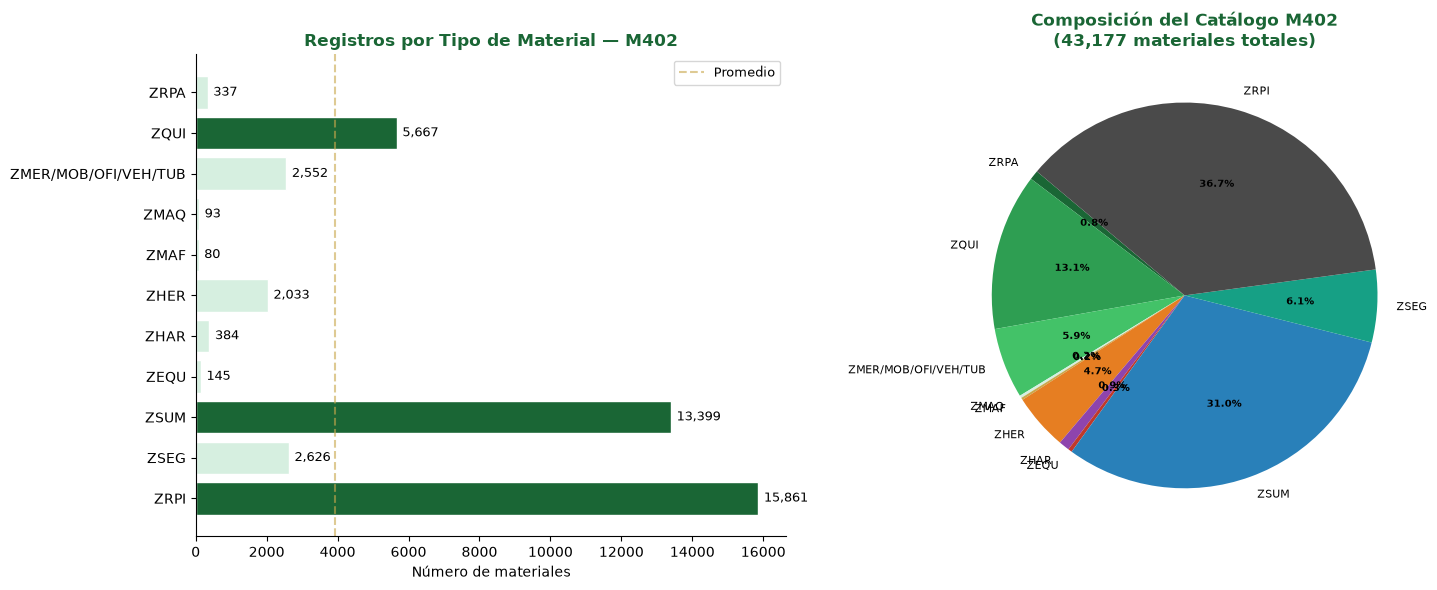

Total registros M402: 43,177


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

tipos_list = list(dfs.keys())
totales = [len(dfs[t]) for t in tipos_list]
total_global = sum(totales)
pcts = [v/total_global*100 for v in totales]

# Barras horizontales
colores_bar = [CMI_VERDE if t in ['ZRPI','ZSUM','ZQUI'] else CMI_CLARO for t in tipos_list]
axes[0].barh(tipos_list[::-1], totales[::-1], color=colores_bar[::-1], edgecolor='white')
for i, (t, v) in enumerate(zip(tipos_list[::-1], totales[::-1])):
    axes[0].text(v + max(totales)*0.01, i, f'{v:,}', va='center', fontsize=9)
axes[0].set_title('Registros por Tipo de Material — M402', fontweight='bold', color=CMI_VERDE, fontsize=12)
axes[0].set_xlabel('Número de materiales')
axes[0].spines[['top','right']].set_visible(False)
axes[0].axvline(total_global/len(tipos_list), color=CMI_ORO, linestyle='--', alpha=0.6, label='Promedio')
axes[0].legend(fontsize=9)

# Pie
wedge_colors = [CMI_VERDE, '#2E9E52', '#43C268', CMI_CLARO, CMI_ORO,
                '#E67E22', '#8E44AD', CMI_ROJO, '#2980B9', '#16A085', CMI_GRIS]
wedges, texts, autotexts = axes[1].pie(
    totales, labels=tipos_list, colors=wedge_colors[:len(tipos_list)],
    autopct='%1.1f%%', startangle=140, textprops={'fontsize': 8}
)
for at in autotexts:
    at.set_fontsize(7)
    at.set_fontweight('bold')
axes[1].set_title(f'Composición del Catálogo M402\n({total_global:,} materiales totales)', 
                  fontweight='bold', color=CMI_VERDE, fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_global_distribucion.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Total registros M402: {total_global:,}')


## 3. Análisis Comparativo de Duplicados por Tipo
> Cota inferior del problema: duplicados con texto breve exactamente igual. El motor pg_trgm de GAMMA detectará muchos más casos con similitud difusa.


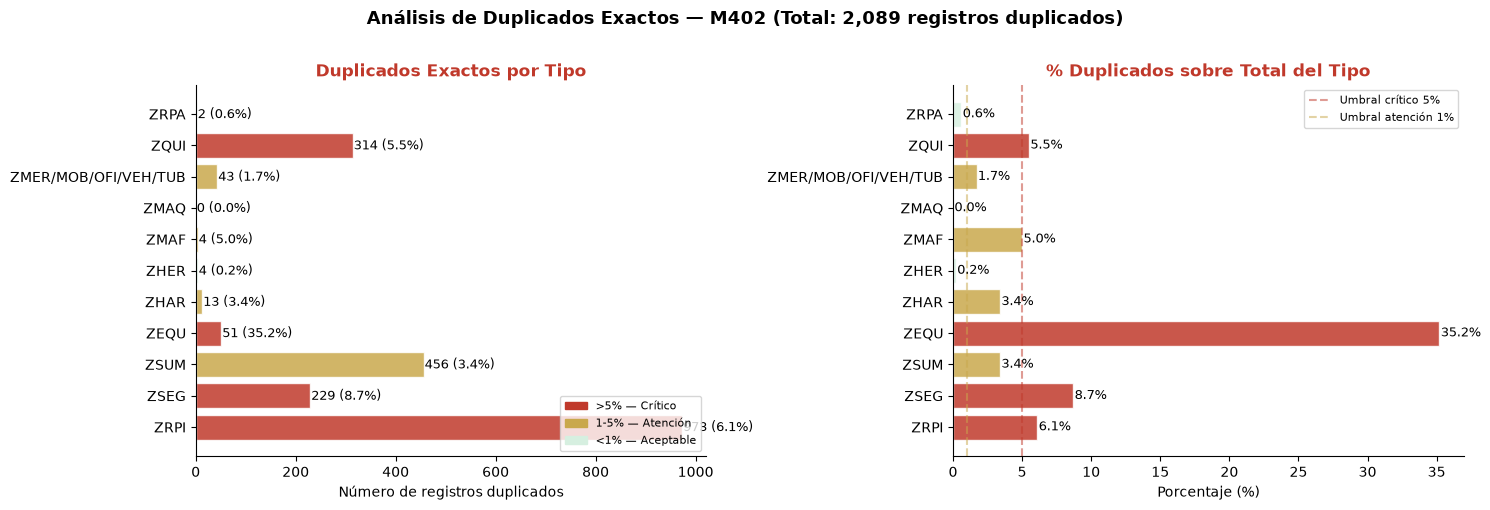

Total duplicados exactos en M402: 2,089
Tipo con más duplicados: ZRPI (973)
Tipo con mayor % duplicados: ZEQU (35.2%)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

tipos_list = list(dfs.keys())
n_dups = []
pct_dups = []

for tipo in tipos_list:
    df = dfs[tipo]
    col_txt = get_col(df, ['Texto breve de material', 'Texto_breve_2'])
    if col_txt:
        n = df.duplicated(subset=[col_txt], keep=False).sum()
    else:
        n = 0
    n_dups.append(n)
    pct_dups.append(round(n/len(df)*100, 1) if len(df) > 0 else 0)

# Barras duplicados absolutos
colores_dup = [CMI_ROJO if p > 5 else CMI_ORO if p > 1 else CMI_CLARO for p in pct_dups]
axes[0].barh(tipos_list[::-1], n_dups[::-1], color=colores_dup[::-1], edgecolor='white', alpha=0.85)
for i, (v, p) in enumerate(zip(n_dups[::-1], pct_dups[::-1])):
    axes[0].text(v + 2, i, f'{v:,} ({p}%)', va='center', fontsize=9)
axes[0].set_title('Duplicados Exactos por Tipo', fontweight='bold', color=CMI_ROJO, fontsize=12)
axes[0].set_xlabel('Número de registros duplicados')
axes[0].spines[['top','right']].set_visible(False)
leyenda = [mpatches.Patch(color=CMI_ROJO, label='>5% — Crítico'),
           mpatches.Patch(color=CMI_ORO, label='1-5% — Atención'),
           mpatches.Patch(color=CMI_CLARO, label='<1% — Aceptable')]
axes[0].legend(handles=leyenda, fontsize=8, loc='lower right')

# Porcentaje
axes[1].barh(tipos_list[::-1], pct_dups[::-1], color=colores_dup[::-1], edgecolor='white', alpha=0.85)
axes[1].axvline(5, color=CMI_ROJO, linestyle='--', alpha=0.5, label='Umbral crítico 5%')
axes[1].axvline(1, color=CMI_ORO, linestyle='--', alpha=0.5, label='Umbral atención 1%')
for i, v in enumerate(pct_dups[::-1]):
    axes[1].text(v + 0.1, i, f'{v}%', va='center', fontsize=9)
axes[1].set_title('% Duplicados sobre Total del Tipo', fontweight='bold', color=CMI_ROJO, fontsize=12)
axes[1].set_xlabel('Porcentaje (%)')
axes[1].legend(fontsize=8)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle(f'Análisis de Duplicados Exactos — M402 (Total: {sum(n_dups):,} registros duplicados)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_global_duplicados.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Total duplicados exactos en M402: {sum(n_dups):,}')
print(f'Tipo con más duplicados: {tipos_list[n_dups.index(max(n_dups))]} ({max(n_dups):,})')
print(f'Tipo con mayor % duplicados: {tipos_list[pct_dups.index(max(pct_dups))]} ({max(pct_dups)}%)')


## 4. Mapa de Calidad de Datos — Vista Consolidada
> Heatmap que muestra el % de problemas por tipo y dimensión de calidad. Verde = saludable, rojo = crítico.


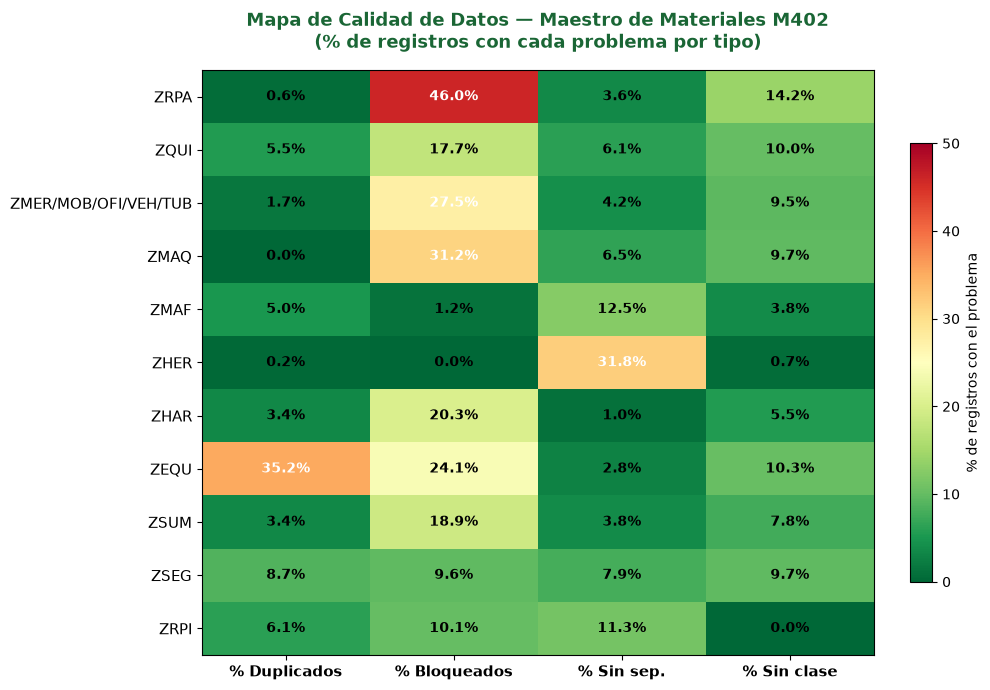

In [6]:
dimensiones = ['% Duplicados', '% Bloqueados', '% Sin sep.', '% Sin clase']
matrix = []

for tipo in tipos_list:
    df = dfs[tipo]
    col_txt = get_col(df, ['Texto breve de material', 'Texto_breve_2'])
    col_pb  = get_col(df, [c for c in df.columns if 'PB' in c or 'nivel' in c.lower()])
    col_cls = get_col(df, ['Denom.estándar', 'Denom. estándar', 'Denominación estándar'])
    
    n = len(df)
    d1 = df.duplicated(subset=[col_txt], keep=False).sum()/n*100 if col_txt and n > 0 else 0
    d2 = (df[col_pb]=='X').sum()/n*100 if col_pb and n > 0 else 0
    tiene_sep = df[col_txt].astype(str).str.contains(r'[:/;]', regex=True) if col_txt else pd.Series([True]*n)
    d3 = (~tiene_sep).sum()/n*100 if n > 0 else 0
    d4 = df[col_cls].isna().sum()/n*100 if col_cls and n > 0 else 0
    matrix.append([round(d1,1), round(d2,1), round(d3,1), round(d4,1)])

matrix_arr = np.array(matrix)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(matrix_arr, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=50)

ax.set_xticks(range(len(dimensiones)))
ax.set_xticklabels(dimensiones, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(tipos_list)))
ax.set_yticklabels(tipos_list, fontsize=11)

for i in range(len(tipos_list)):
    for j in range(len(dimensiones)):
        val = matrix_arr[i, j]
        color = 'white' if val > 25 else 'black'
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=10, fontweight='bold', color=color)

plt.colorbar(im, ax=ax, label='% de registros con el problema', fraction=0.03)
ax.set_title('Mapa de Calidad de Datos — Maestro de Materiales M402\n(% de registros con cada problema por tipo)',
             fontsize=13, fontweight='bold', color=CMI_VERDE, pad=16)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_global_calidad_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


## 5. Longitud Promedio de Descripción por Tipo

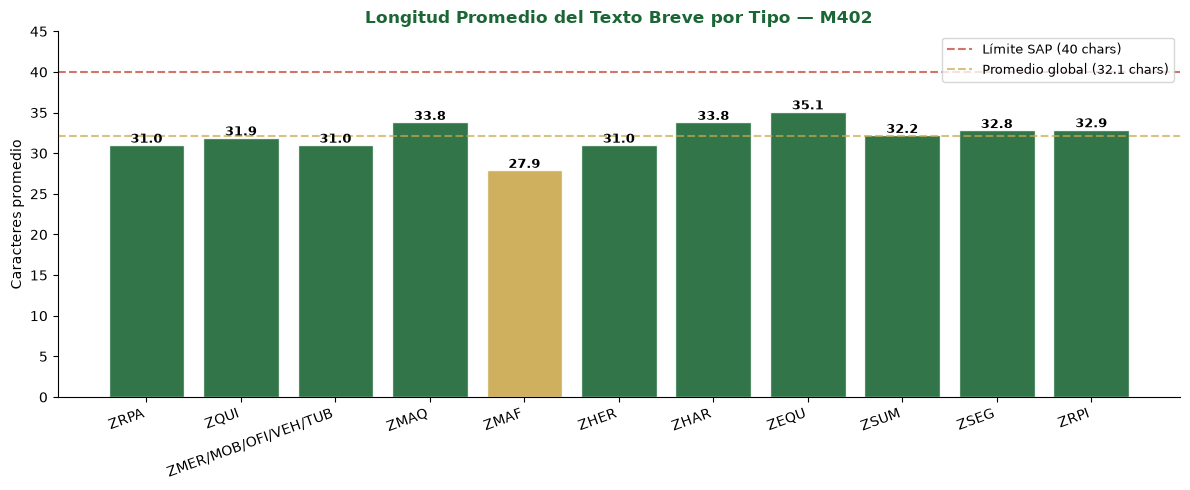

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))

avg_lens = []
for tipo in tipos_list:
    df = dfs[tipo]
    col_txt = get_col(df, ['Texto breve de material', 'Texto_breve_2'])
    avg = df[col_txt].astype(str).str.len().mean() if col_txt else 0
    avg_lens.append(round(avg, 1))

colores_len = [CMI_VERDE if v >= 30 else CMI_ORO if v >= 20 else CMI_ROJO for v in avg_lens]
bars = ax.bar(tipos_list, avg_lens, color=colores_len, edgecolor='white', alpha=0.9)
ax.axhline(40, color=CMI_ROJO, linestyle='--', alpha=0.7, label='Límite SAP (40 chars)')
ax.axhline(np.mean(avg_lens), color=CMI_ORO, linestyle='--', alpha=0.7, 
           label=f'Promedio global ({np.mean(avg_lens):.1f} chars)')
for bar, val in zip(bars, avg_lens):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Caracteres promedio')
ax.set_title('Longitud Promedio del Texto Breve por Tipo — M402', 
             fontweight='bold', color=CMI_VERDE, fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0, 45)
ax.spines[['top','right']].set_visible(False)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_global_longitud.png'), dpi=150, bbox_inches='tight')
plt.show()


## 6. Análisis Individual por Tipo
> Las siguientes celdas ejecutan el análisis completo para cada tipo. Las gráficas individuales se guardan como PNG.



  ZRPA — 337 registros


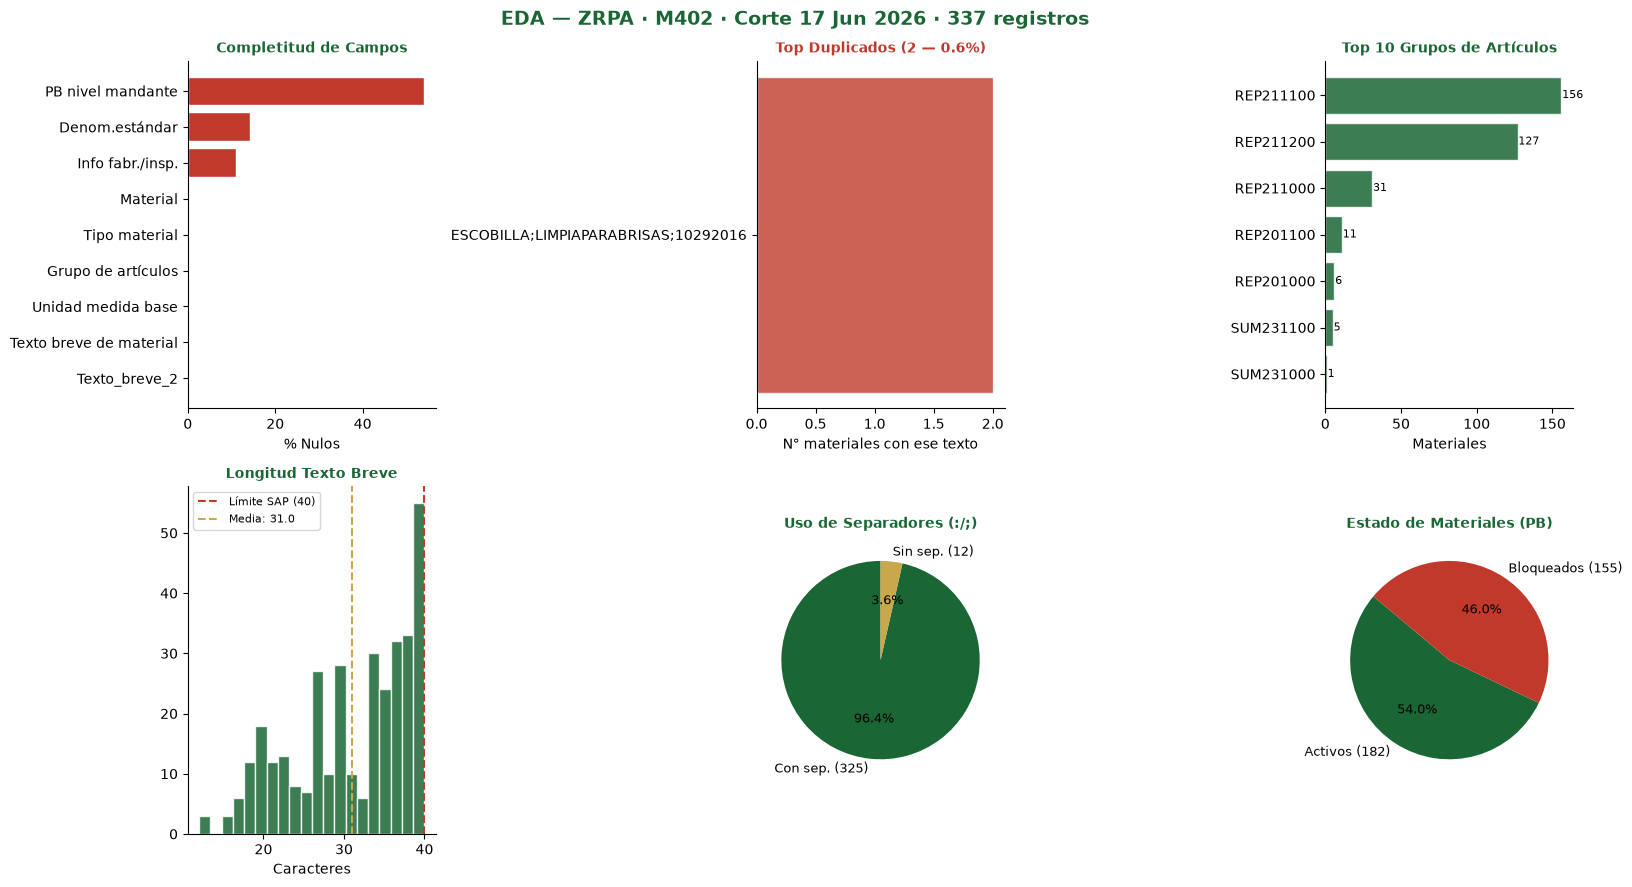

  Registros:              337
  Duplicados exactos:       2  (0.6%)
  Sin separador:           12  (3.6%)
  Bloqueados:             155  (46.0%)

  ZQUI — 5,667 registros


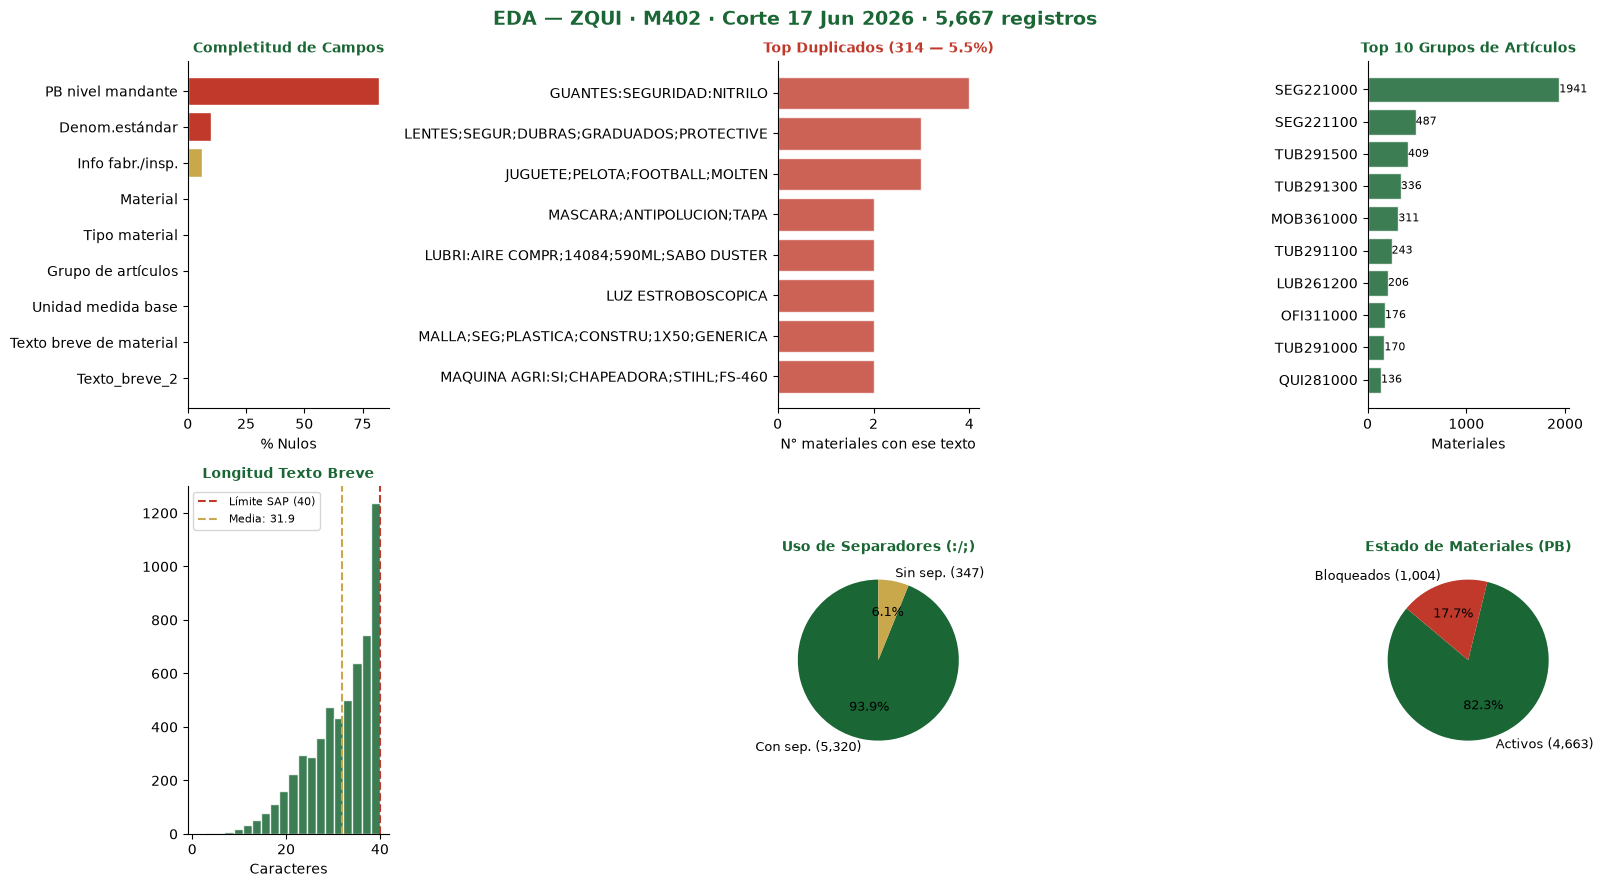

  Registros:            5,667
  Duplicados exactos:     314  (5.5%)
  Sin separador:          347  (6.1%)
  Bloqueados:           1,004  (17.7%)

  ZMER/MOB/OFI/VEH/TUB — 2,552 registros


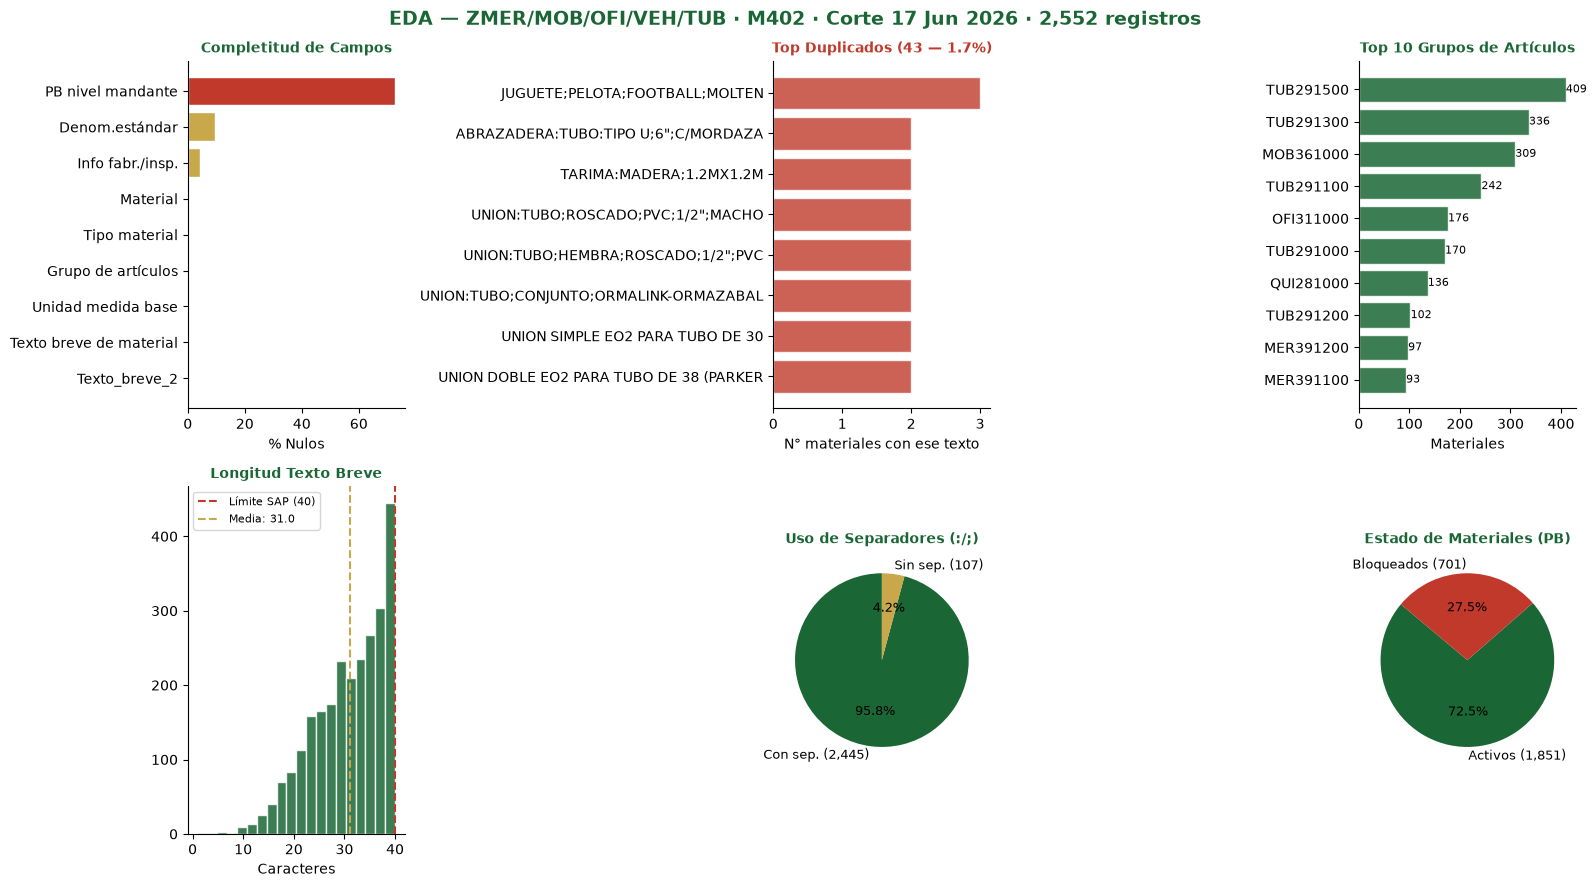

  Registros:            2,552
  Duplicados exactos:      43  (1.7%)
  Sin separador:          107  (4.2%)
  Bloqueados:             701  (27.5%)

  ZMAQ — 93 registros


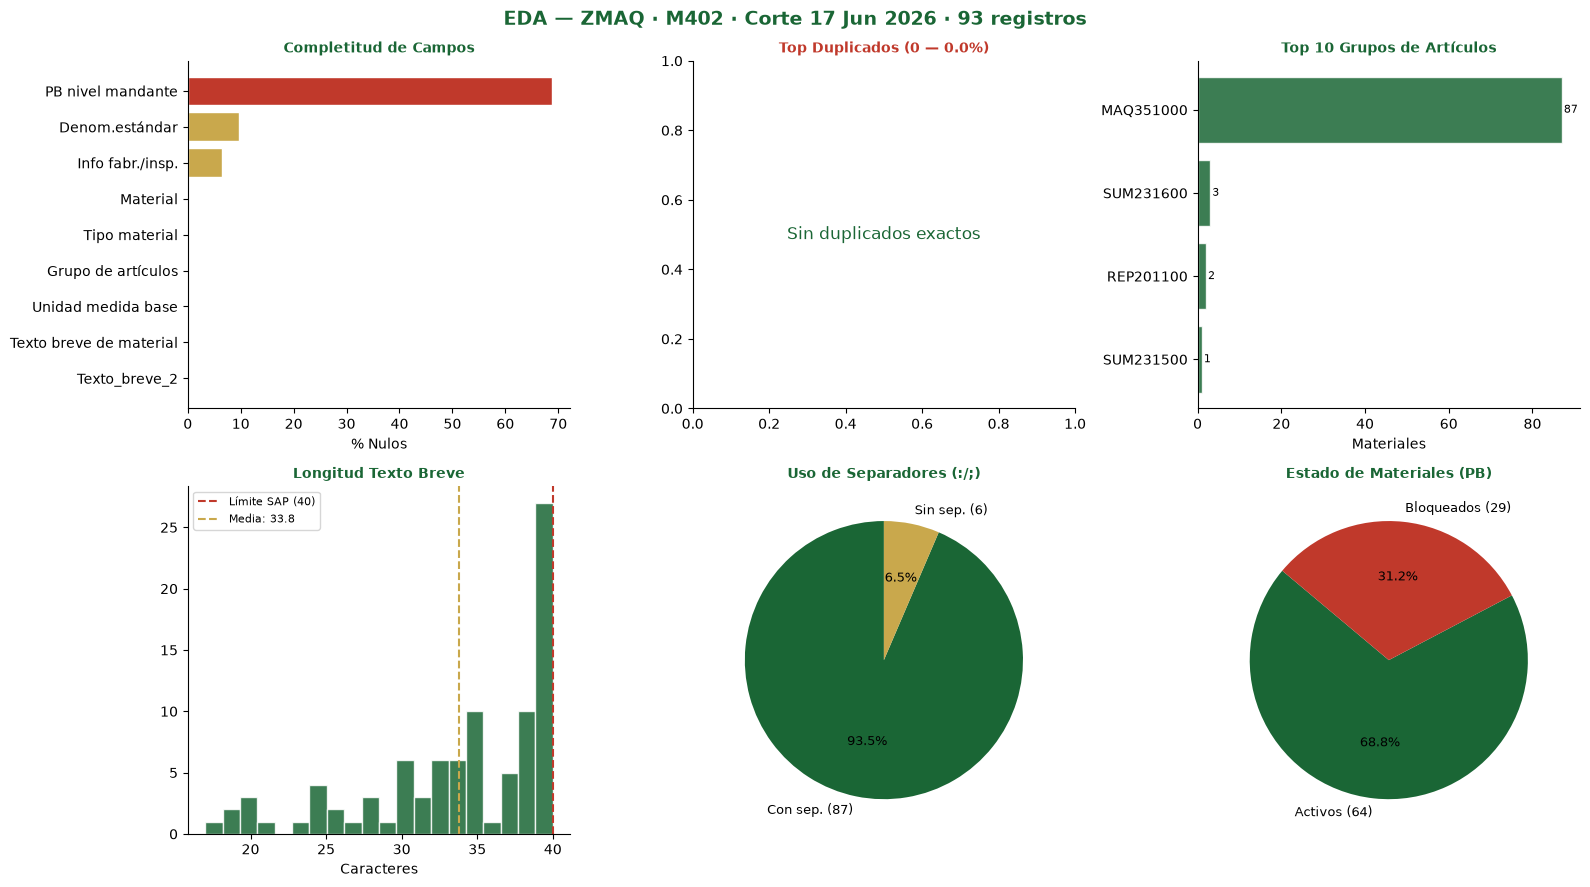

  Registros:               93
  Duplicados exactos:       0  (0.0%)
  Sin separador:            6  (6.5%)
  Bloqueados:              29  (31.2%)

  ZMAF — 80 registros


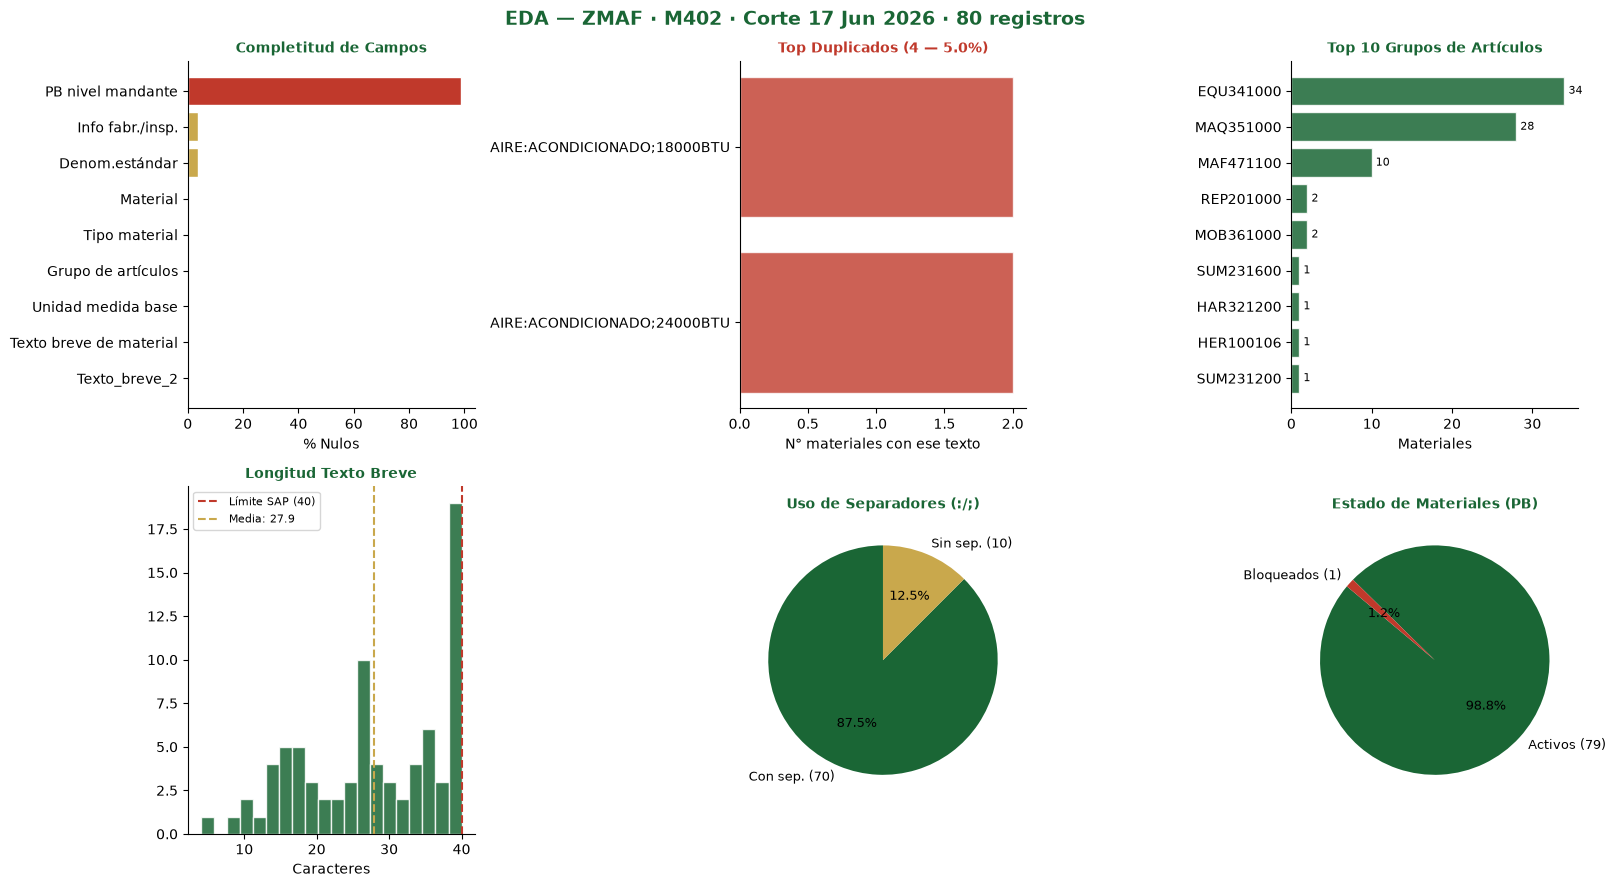

  Registros:               80
  Duplicados exactos:       4  (5.0%)
  Sin separador:           10  (12.5%)
  Bloqueados:               1  (1.2%)

  ZHER — 2,033 registros


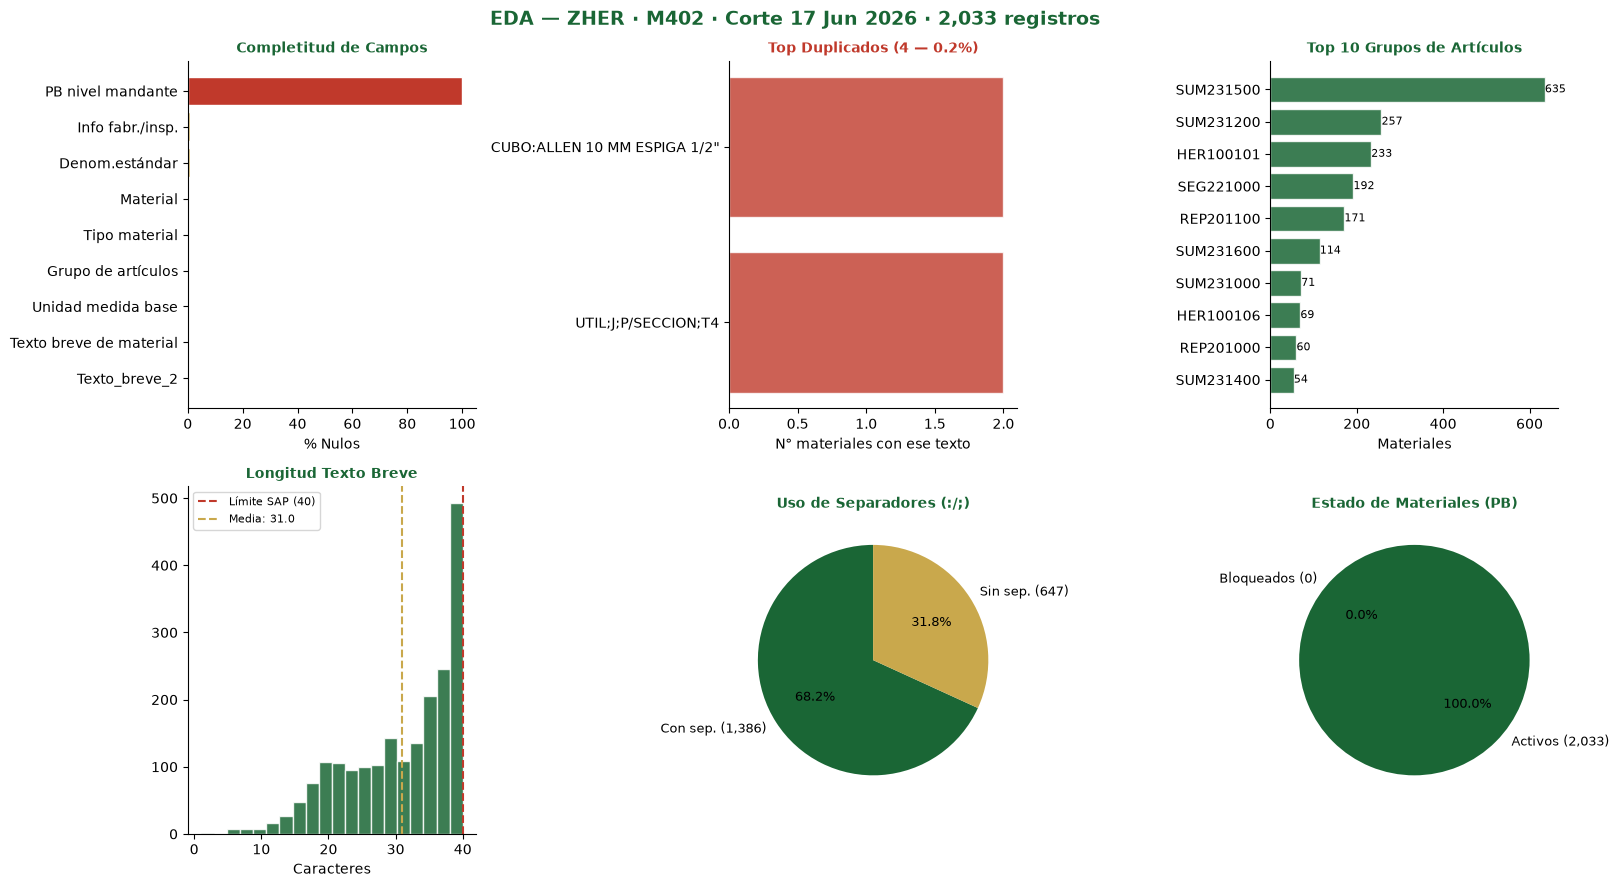

  Registros:            2,033
  Duplicados exactos:       4  (0.2%)
  Sin separador:          647  (31.8%)
  Bloqueados:               0  (0.0%)

  ZHAR — 384 registros


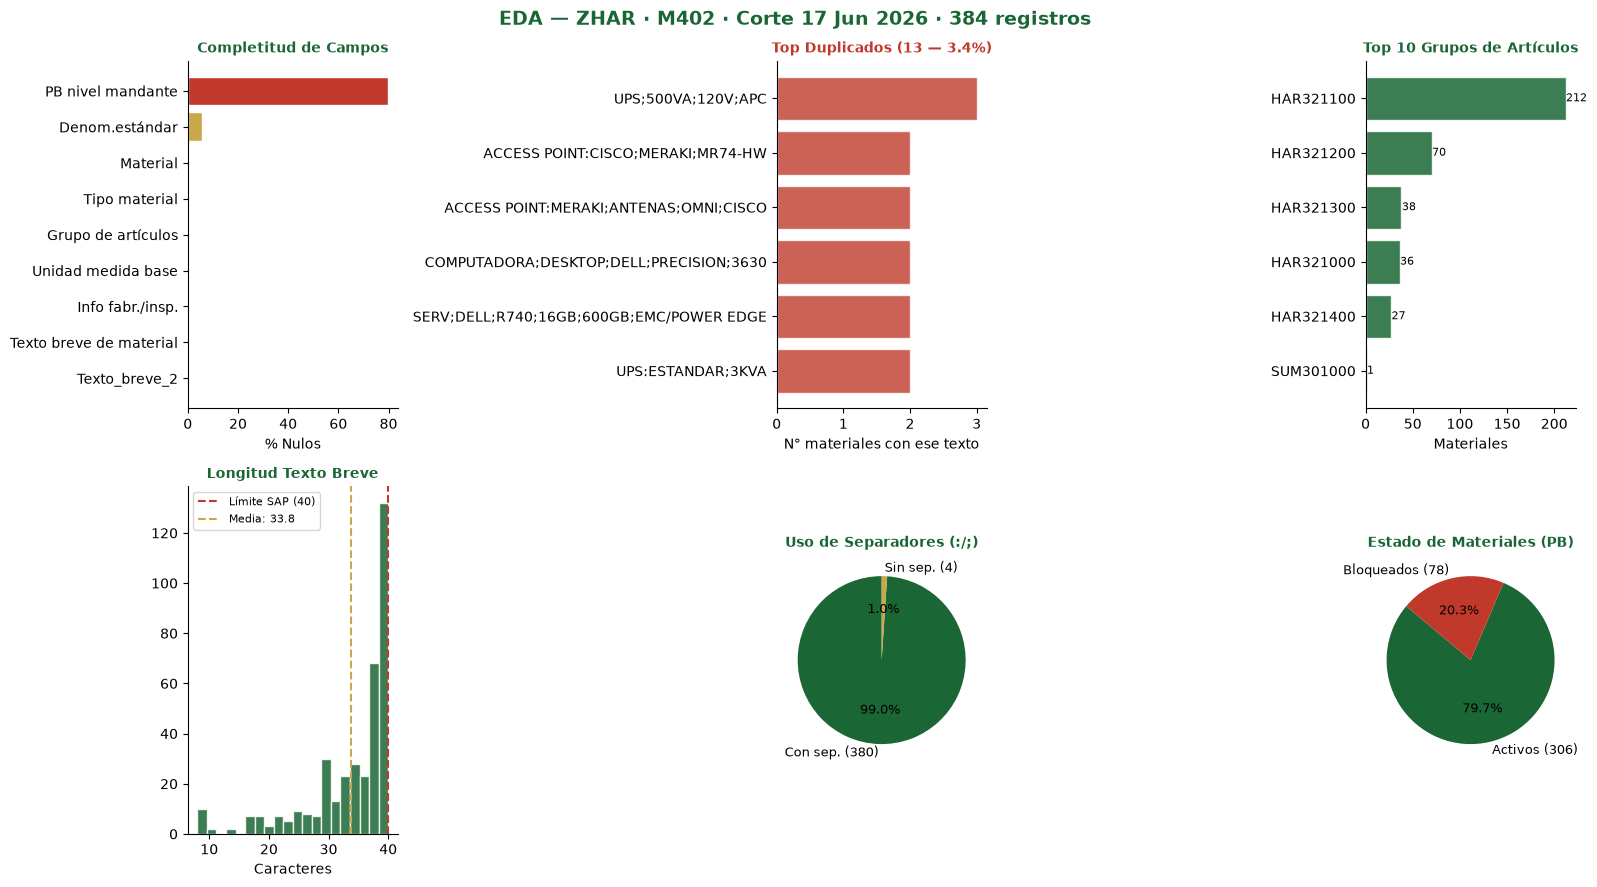

  Registros:              384
  Duplicados exactos:      13  (3.4%)
  Sin separador:            4  (1.0%)
  Bloqueados:              78  (20.3%)

  ZEQU — 145 registros


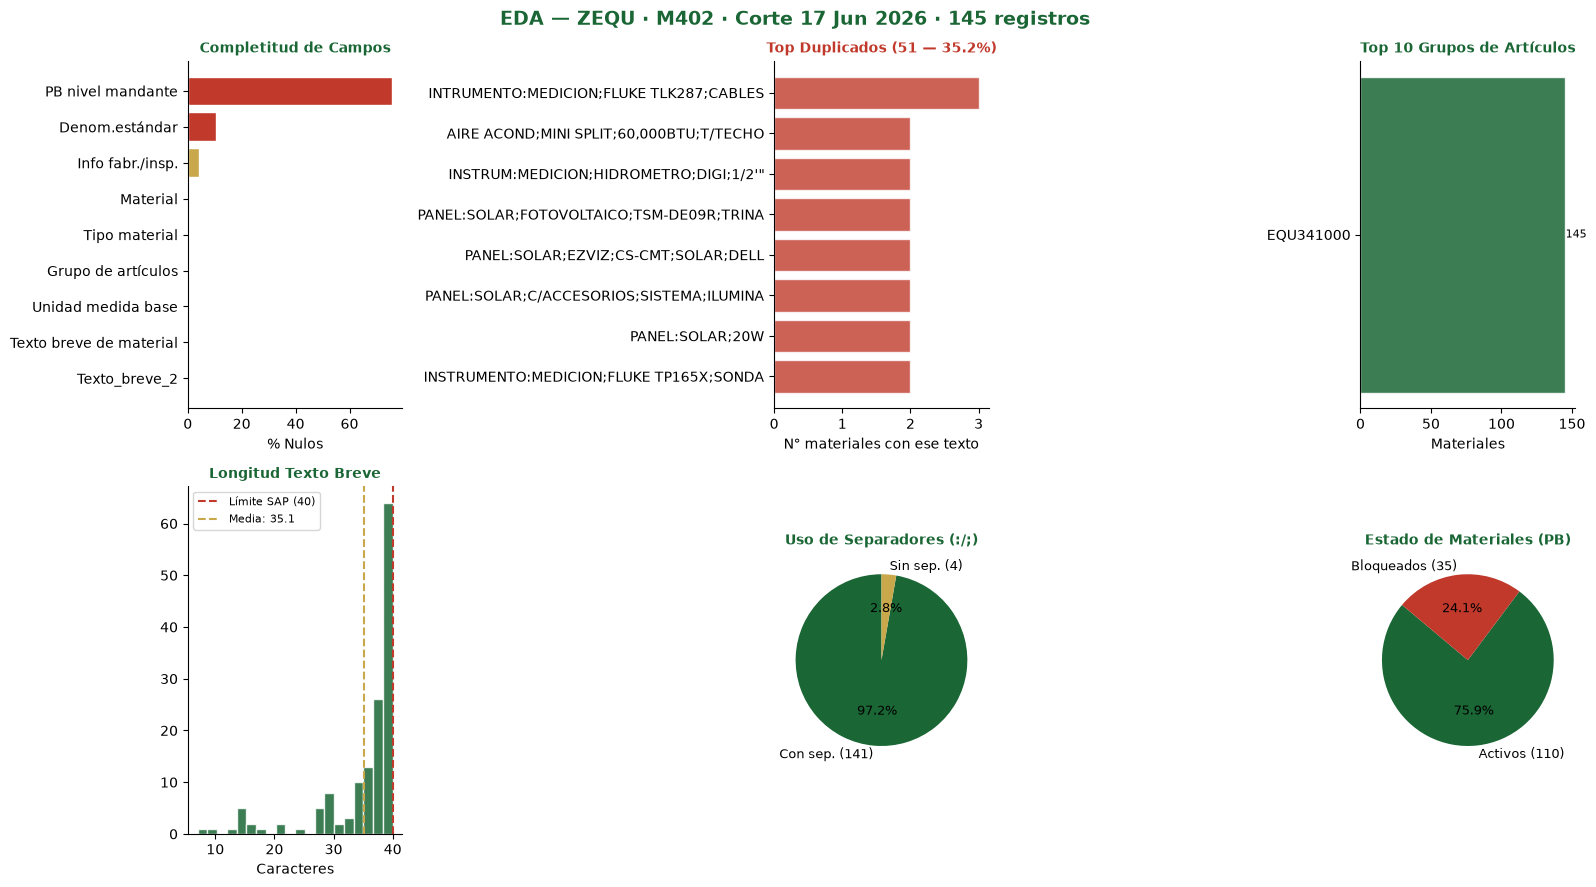

  Registros:              145
  Duplicados exactos:      51  (35.2%)
  Sin separador:            4  (2.8%)
  Bloqueados:              35  (24.1%)

  ZSUM — 13,399 registros


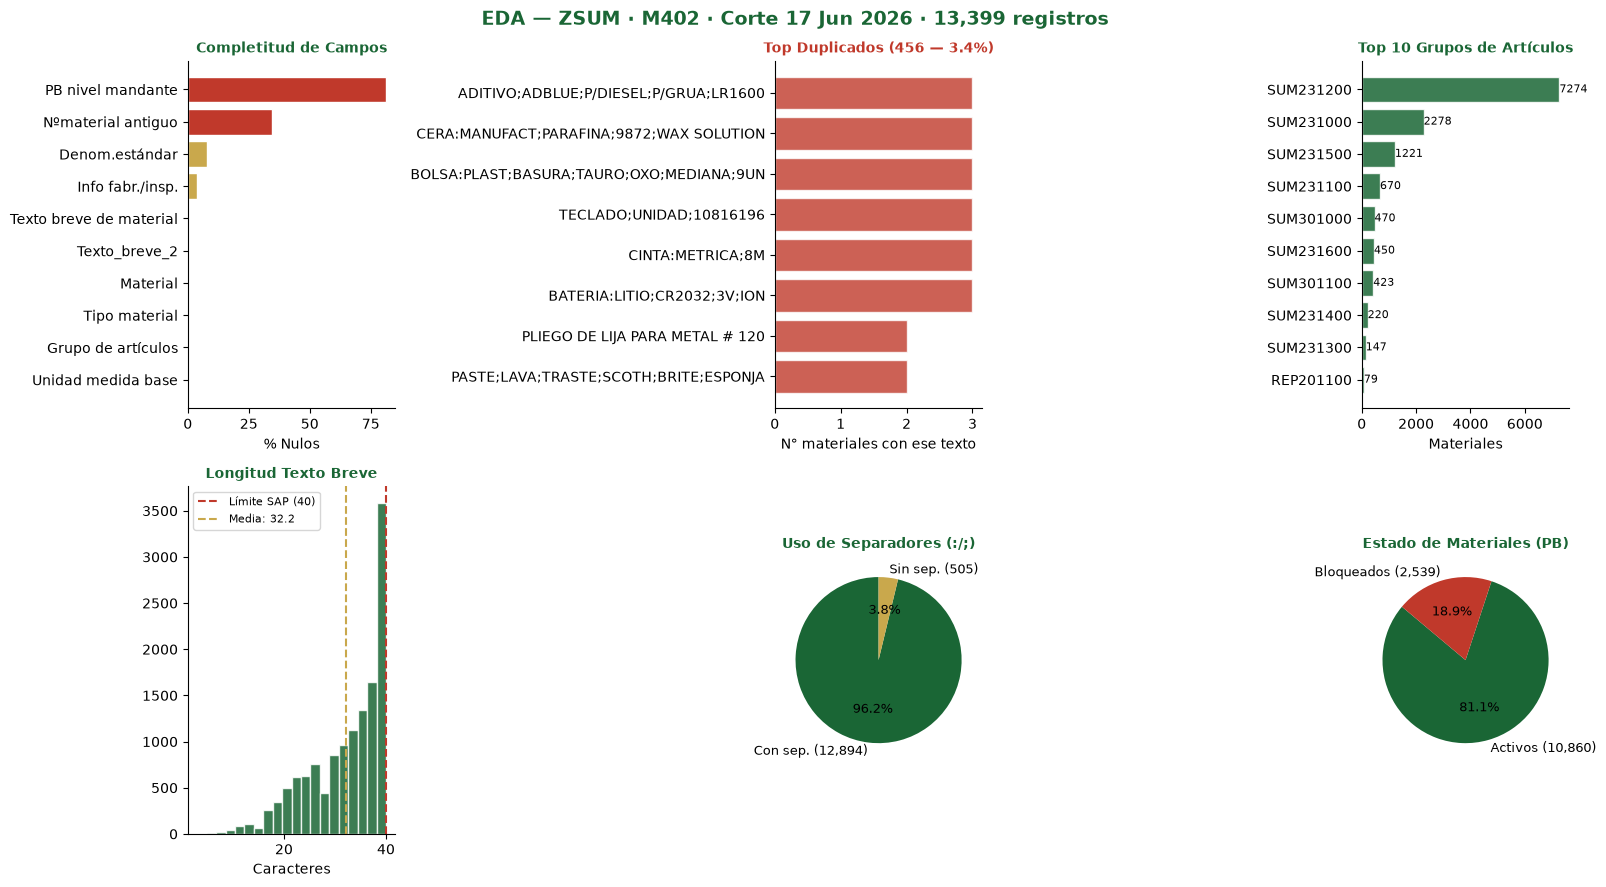

  Registros:           13,399
  Duplicados exactos:     456  (3.4%)
  Sin separador:          505  (3.8%)
  Bloqueados:           2,539  (18.9%)

  ZSEG — 2,626 registros


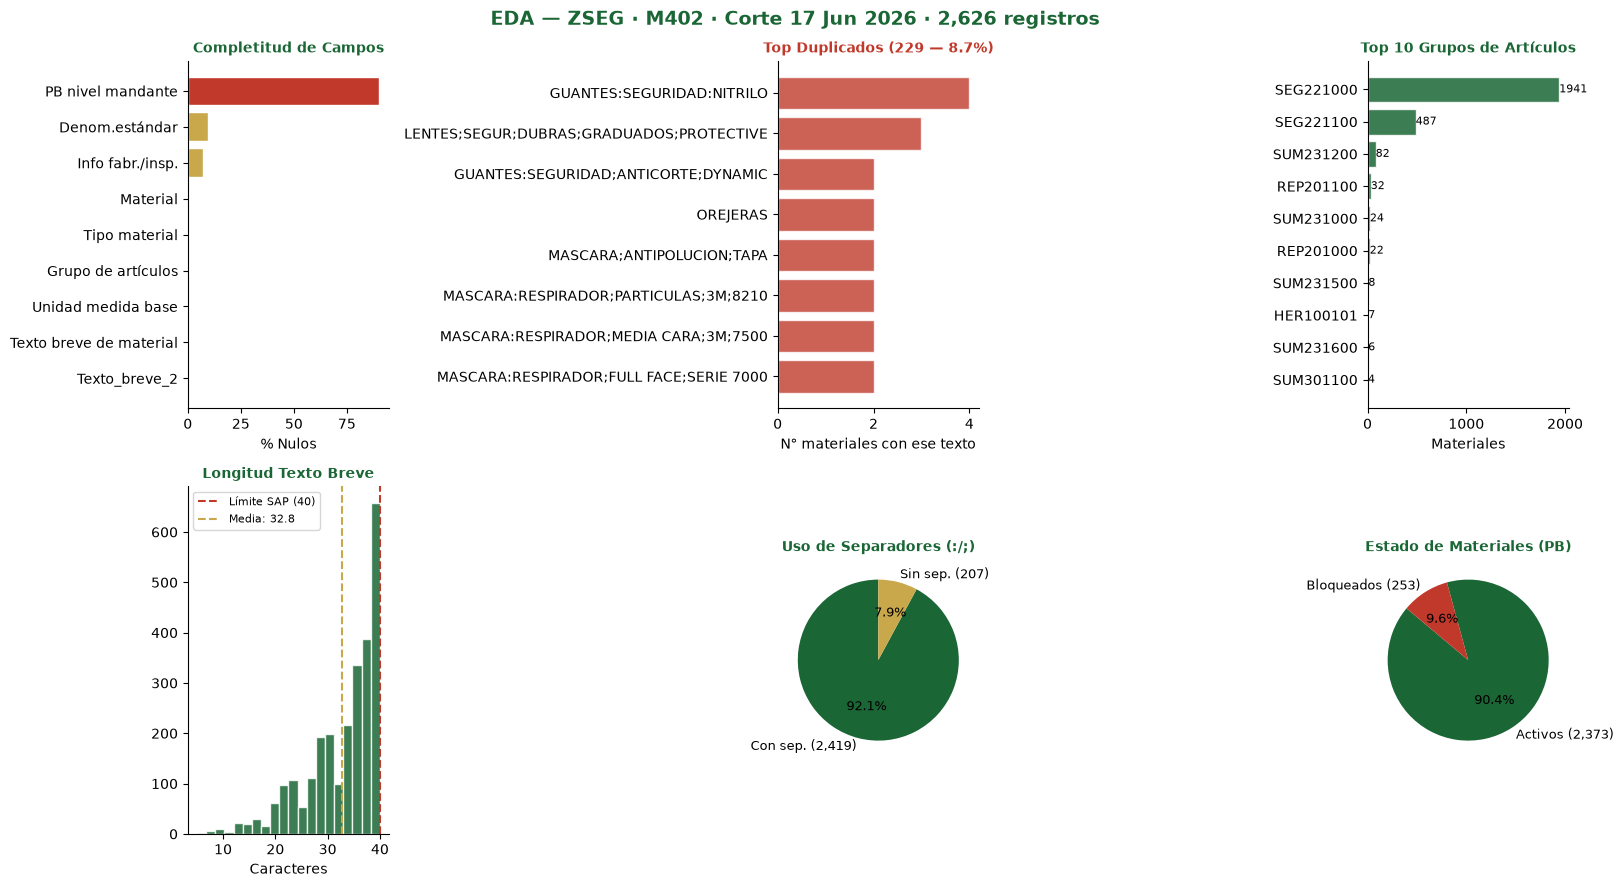

  Registros:            2,626
  Duplicados exactos:     229  (8.7%)
  Sin separador:          207  (7.9%)
  Bloqueados:             253  (9.6%)

  ZRPI — 15,861 registros


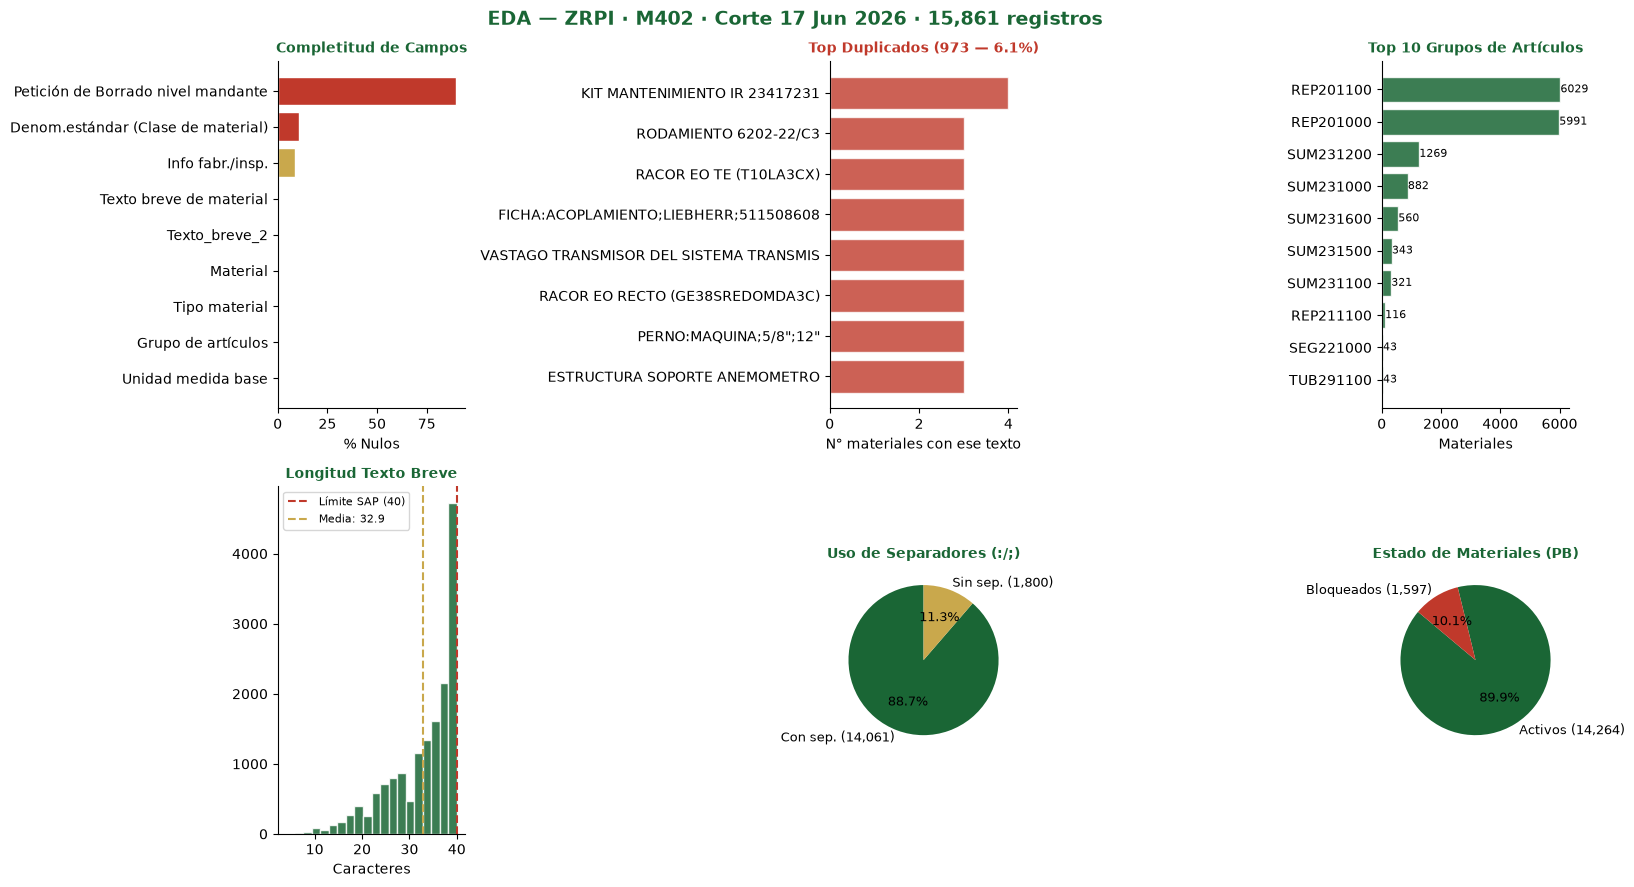

  Registros:           15,861
  Duplicados exactos:     973  (6.1%)
  Sin separador:        1,800  (11.3%)
  Bloqueados:           1,597  (10.1%)


In [8]:
# ── Función de análisis individual ──────────────────────────────────────
def analizar_tipo(tipo, df):
    print(f'\n{"="*60}')
    print(f'  {tipo} — {len(df):,} registros')
    print(f'{"="*60}')
    
    col_txt = get_col(df, ['Texto breve de material', 'Texto_breve_2'])
    col_grp = get_col(df, ['Grupo de artículos', 'Grupo de Artículos'])
    col_um  = get_col(df, ['Unidad medida base', 'Unidad de medida base'])
    col_pb  = get_col(df, [c for c in df.columns if 'PB' in c or 'nivel' in c.lower()])
    col_cls = get_col(df, ['Denom.estándar', 'Denom. estándar', 'Denominación estándar'])
    
    n = len(df)
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(f'EDA — {tipo} · M402 · Corte 17 Jun 2026 · {n:,} registros',
                 fontsize=14, fontweight='bold', color=CMI_VERDE)
    
    # 1. Completitud
    nulos = df.isnull().mean().sort_values(ascending=False) * 100
    colores_n = [CMI_ROJO if v > 10 else CMI_ORO if v > 0 else CMI_VERDE for v in nulos.values]
    axes[0,0].barh(nulos.index[::-1], nulos.values[::-1], color=colores_n[::-1], edgecolor='white')
    axes[0,0].set_title('Completitud de Campos', fontweight='bold', color=CMI_VERDE, fontsize=10)
    axes[0,0].set_xlabel('% Nulos')
    axes[0,0].spines[['top','right']].set_visible(False)
    
    # 2. Duplicados
    if col_txt:
        dup_mask = df.duplicated(subset=[col_txt], keep=False)
        top_dup = (df[dup_mask].groupby(col_txt)['Material'].count()
                   .sort_values(ascending=False).head(8)) if dup_mask.sum() > 0 else pd.Series()
        if len(top_dup) > 0:
            axes[0,1].barh(top_dup.index[::-1], top_dup.values[::-1], 
                           color=CMI_ROJO, alpha=0.8, edgecolor='white')
            axes[0,1].set_xlabel('N° materiales con ese texto')
        else:
            axes[0,1].text(0.5, 0.5, 'Sin duplicados exactos', ha='center', va='center',
                           transform=axes[0,1].transAxes, fontsize=12, color=CMI_VERDE)
        axes[0,1].set_title(f'Top Duplicados ({dup_mask.sum():,} — {dup_mask.sum()/n*100:.1f}%)', 
                            fontweight='bold', color=CMI_ROJO, fontsize=10)
        axes[0,1].spines[['top','right']].set_visible(False)
    
    # 3. Grupos de artículos
    if col_grp:
        grp = df[col_grp].value_counts().head(10)
        axes[0,2].barh(grp.index[::-1], grp.values[::-1], color=CMI_VERDE, alpha=0.85, edgecolor='white')
        for i, v in enumerate(grp.values[::-1]):
            axes[0,2].text(v + 0.5, i, str(v), va='center', fontsize=8)
        axes[0,2].set_title('Top 10 Grupos de Artículos', fontweight='bold', color=CMI_VERDE, fontsize=10)
        axes[0,2].set_xlabel('Materiales')
        axes[0,2].spines[['top','right']].set_visible(False)
    
    # 4. Longitud descripción
    if col_txt:
        lens = df[col_txt].astype(str).str.len()
        axes[1,0].hist(lens, bins=20, color=CMI_VERDE, edgecolor='white', alpha=0.85)
        axes[1,0].axvline(40, color=CMI_ROJO, linestyle='--', label='Límite SAP (40)')
        axes[1,0].axvline(lens.mean(), color=CMI_ORO, linestyle='--', label=f'Media: {lens.mean():.1f}')
        axes[1,0].set_title('Longitud Texto Breve', fontweight='bold', color=CMI_VERDE, fontsize=10)
        axes[1,0].set_xlabel('Caracteres')
        axes[1,0].legend(fontsize=8)
        axes[1,0].spines[['top','right']].set_visible(False)
    
    # 5. Separadores
    if col_txt:
        tiene_sep = df[col_txt].astype(str).str.contains(r'[:/;]', regex=True)
        con_sep = tiene_sep.sum()
        sin_sep = (~tiene_sep).sum()
        axes[1,1].pie([con_sep, sin_sep],
                      labels=[f'Con sep. ({con_sep:,})', f'Sin sep. ({sin_sep:,})'],
                      colors=[CMI_VERDE, CMI_ORO], autopct='%1.1f%%',
                      startangle=90, textprops={'fontsize':9})
        axes[1,1].set_title('Uso de Separadores (:/;)', fontweight='bold', color=CMI_VERDE, fontsize=10)
    
    # 6. Bloqueados
    if col_pb:
        bloq = (df[col_pb]=='X').sum()
        actv = n - bloq
        axes[1,2].pie([actv, bloq],
                      labels=[f'Activos ({actv:,})', f'Bloqueados ({bloq:,})'],
                      colors=[CMI_VERDE, CMI_ROJO], autopct='%1.1f%%',
                      startangle=140, textprops={'fontsize':9})
        axes[1,2].set_title('Estado de Materiales (PB)', fontweight='bold', color=CMI_VERDE, fontsize=10)
    
    plt.tight_layout()
    fname = f'fig_individual_{tipo.replace("/","_")}.png'
    plt.savefig(os.path.join(FIG_DIR, fname), dpi=150, bbox_inches='tight')
    plt.show()
    
    # Resumen
    print(f'  Registros:         {n:>8,}')
    if col_txt:
        dup_n = df.duplicated(subset=[col_txt], keep=False).sum()
        print(f'  Duplicados exactos:{dup_n:>8,}  ({dup_n/n*100:.1f}%)')
        sin_s = (~df[col_txt].astype(str).str.contains(r"[:/;]", regex=True)).sum()
        print(f'  Sin separador:     {sin_s:>8,}  ({sin_s/n*100:.1f}%)')
    if col_pb:
        bloq = (df[col_pb]=='X').sum()
        print(f'  Bloqueados:        {bloq:>8,}  ({bloq/n*100:.1f}%)')

# ── Ejecutar para todos los tipos ───────────────────────────────────────
for tipo, df in dfs.items():
    analizar_tipo(tipo, df)


## 7. Resumen Consolidado de Hallazgos y Justificación de GAMMA
> Este resumen alimenta directamente la sección III del protocolo académico y el documento escrito final.


In [9]:
print('=' * 70)
print('HALLAZGOS CRÍTICOS — EDA COMPLETO MAESTRO M402')
print(f'Fecha de corte: 29 de mayo 2026')
print('=' * 70)

total_reg = sum(len(df) for df in dfs.values())
total_dup = 0
total_bloq = 0
total_sin_sep = 0
tipo_max_dup_pct = ('', 0)
tipo_max_bloq_pct = ('', 0)

for tipo, df in dfs.items():
    col_txt = get_col(df, ['Texto breve de material', 'Texto_breve_2'])
    col_pb  = get_col(df, [c for c in df.columns if 'PB' in c or 'nivel' in c.lower()])
    n = len(df)
    
    if col_txt:
        nd = df.duplicated(subset=[col_txt], keep=False).sum()
        total_dup += nd
        ns = (~df[col_txt].astype(str).str.contains(r"[:/;]", regex=True)).sum()
        total_sin_sep += ns
        if nd/n*100 > tipo_max_dup_pct[1]:
            tipo_max_dup_pct = (tipo, round(nd/n*100,1))
    
    if col_pb:
        nb = (df[col_pb]=='X').sum()
        total_bloq += nb
        if nb/n*100 > tipo_max_bloq_pct[1]:
            tipo_max_bloq_pct = (tipo, round(nb/n*100,1))

print(f'  Total de materiales analizados:        {total_reg:>10,}')
print(f'  Tipos de material cubiertos:           {len(dfs):>10}')
print(f'  Duplicados exactos totales:            {total_dup:>10,}  ({total_dup/total_reg*100:.1f}%)')
print(f'  Registros bloqueados (PB=X):           {total_bloq:>10,}  ({total_bloq/total_reg*100:.1f}%)')
print(f'  Sin separador estándar:                {total_sin_sep:>10,}  ({total_sin_sep/total_reg*100:.1f}%)')
print(f'  Tipo con mayor % duplicados:           {tipo_max_dup_pct[0]:<15} ({tipo_max_dup_pct[1]}%)')
print(f'  Tipo con mayor % bloqueados:           {tipo_max_bloq_pct[0]:<15} ({tipo_max_bloq_pct[1]}%)')
print('=' * 70)
print()
print('IMPACTO ESPERADO DE GAMMA:')
print(f'  Motor pg_trgm detectará duplicados SEMÁNTICOS adicionales a los {total_dup:,}')
print(f'  exactos confirmados, incluyendo variaciones de abreviación y formato.')
print(f'  Los {total_sin_sep:,} registros sin separador son los de mayor riesgo de')
print(f'  duplicidad no detectada por búsqueda exacta.')


HALLAZGOS CRÍTICOS — EDA COMPLETO MAESTRO M402
Fecha de corte: 29 de mayo 2026
  Total de materiales analizados:            43,177
  Tipos de material cubiertos:                   11
  Duplicados exactos totales:                 2,089  (4.8%)
  Registros bloqueados (PB=X):                6,392  (14.8%)
  Sin separador estándar:                     3,649  (8.5%)
  Tipo con mayor % duplicados:           ZEQU            (35.2%)
  Tipo con mayor % bloqueados:           ZRPA            (46.0%)

IMPACTO ESPERADO DE GAMMA:
  Motor pg_trgm detectará duplicados SEMÁNTICOS adicionales a los 2,089
  exactos confirmados, incluyendo variaciones de abreviación y formato.
  Los 3,649 registros sin separador son los de mayor riesgo de
  duplicidad no detectada por búsqueda exacta.
